In [1]:
import ast
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import numpy as np
import pandas as pd

In [2]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
device

device(type='mps')

In [11]:
class DDXPlusDatasetLoader(Dataset):
    def __init__(self, csv_filepath):
        print("Loading Massive dataset into Memory")
        # load the dataset into memory
        self.df = pd.read_csv(csv_filepath)
        print(f'Pandas can see the columns: {self.df.columns.tolist()}')

        # changing the EVIDENCES column to column of lists instead of str.
        # print(f'Formatting each EVIDENCE in EVIDENCES column to a list instead of str using ast.literal_eval')
        # self.df['EVIDENCES'] = self.df['EVIDENCES'].apply(ast.literal_eval)

        # lets forumlate disease to index dictionary.
        print("Mapping symptoms and diseases to numerical indices...")
        self.all_diseases = self.df['PATHOLOGY'].unique().tolist()
        self.disease_to_idx = {d: i for i, d in enumerate(self.all_diseases)}

        # extract all unique symptoms
        all_symptoms = set()
        for evidences in self.df['EVIDENCES']:
            symptoms_list = ast.literal_eval(evidences)
            all_symptoms.update(symptoms_list)
        # all_symptoms = set(evidences for evidences in self.df['EVIDENCES'])

        # lets formulate symptom to index dictionary
        self.all_symptoms = list(all_symptoms)
        self.symptom_to_idx = {s: i for i, s in enumerate(self.all_symptoms)}

        '''-------------Some debugging lines----------–'''
        # print("\nDisease dictionary: ")
        # for d, i in self.disease_to_idx.items():
        #     print(d, i)
        #     if i == 5:
        #         break

        # print("\nSymptom dictionary: ")
        # for s, i in self.symptom_to_idx.items():
        #     print(s, i)
        #     if i == 5:
        #         break

        self.num_symptoms = len(self.all_symptoms)
        self.num_classes = len(self.all_diseases)

        print(f'No. of unique symptoms and diseases detected are: {self.num_symptoms} and {self.num_classes}')

    def __len__(self):
        return len(self.df)

    # to return one-hot encoded symptom list and its class (disease)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        #create a vector of tensor type of all zeros. Flip to 1.0 as per evidence index
        x_tensor = torch.zeros(self.num_symptoms, dtype=torch.float32)
        patient_symptoms = ast.literal_eval(row['EVIDENCES'])
        for symptom in patient_symptoms:
            symptom_idx = self.symptom_to_idx[symptom]
            # flip to 1.0
            x_tensor[symptom_idx] = 1.0

        y_idx = self.disease_to_idx[row['PATHOLOGY']]
        y_tensor = torch.tensor(y_idx, dtype=torch.long)

        return x_tensor, y_tensor

'''
By inheriting nn.Module class we get the ability to track gradients, move data to M4 GPU and save model weights.
'''
class DDXClinicalTriageModel(nn.Module):
    def __init__(self, input_size, num_classes):
        '''
        Explicitly tell python to run super method, gives mechanism to track math update gradients.
        '''
        super(DDXClinicalTriageModel, self).__init__()
        self.linear = nn.Linear(input_size, num_classes)

    def forward(self, x):
        return self.linear(x)

In [10]:
csv_path = "../data/raw/release_train_patients.csv"

dataset = DDXPlusDatasetLoader(csv_path)

dataloader = DataLoader(dataset, batch_size=1024, shuffle=True)

model = DDXClinicalTriageModel(dataset.num_symptoms, dataset.num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

epochs = 20

print(f'\nStarting Training loop:')

for epoch in range(epochs):
    epoch_loss = 0.0
    for batch_X, batch_y in dataloader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    print(f'Epoch: {epoch+1}/{epochs}, Loss: {epoch_loss/len(dataloader):.4f}')
        
print("✅ Enterprise Training Complete!")

Loading Massive dataset into Memory
Pandas can see the columns: ['AGE', 'DIFFERENTIAL_DIAGNOSIS', 'SEX', 'PATHOLOGY', 'EVIDENCES', 'INITIAL_EVIDENCE']
Mapping symptoms and diseases to numerical indices...
Symptoms dictionary: 
URTI 0
HIV (initial infection) 1
Pneumonia 2
Chronic rhinosinusitis 3
Viral pharyngitis 4
Anemia 5
Diseases dictionary: 
E_105 0
E_99 1
E_42 2
E_59_@_8 3
E_57_@_V_194 4
E_54_@_V_11 5
No. of unique symptoms and diseases detected are: 515 and 49

Starting Training loop:
Epoch: 1/20, Loss: 0.0675
Epoch: 2/20, Loss: 0.0096
Epoch: 3/20, Loss: 0.0085
Epoch: 4/20, Loss: 0.0080
Epoch: 5/20, Loss: 0.0079
Epoch: 6/20, Loss: 0.0079
Epoch: 7/20, Loss: 0.0077
Epoch: 8/20, Loss: 0.0077
Epoch: 9/20, Loss: 0.0076
Epoch: 10/20, Loss: 0.0077
Epoch: 11/20, Loss: 0.0077
Epoch: 12/20, Loss: 0.0076
Epoch: 13/20, Loss: 0.0077
Epoch: 14/20, Loss: 0.0076
Epoch: 15/20, Loss: 0.0076
Epoch: 16/20, Loss: 0.0076
Epoch: 17/20, Loss: 0.0076
Epoch: 18/20, Loss: 0.0076
Epoch: 19/20, Loss: 0.0076


✅ Saved loss_curve.png!


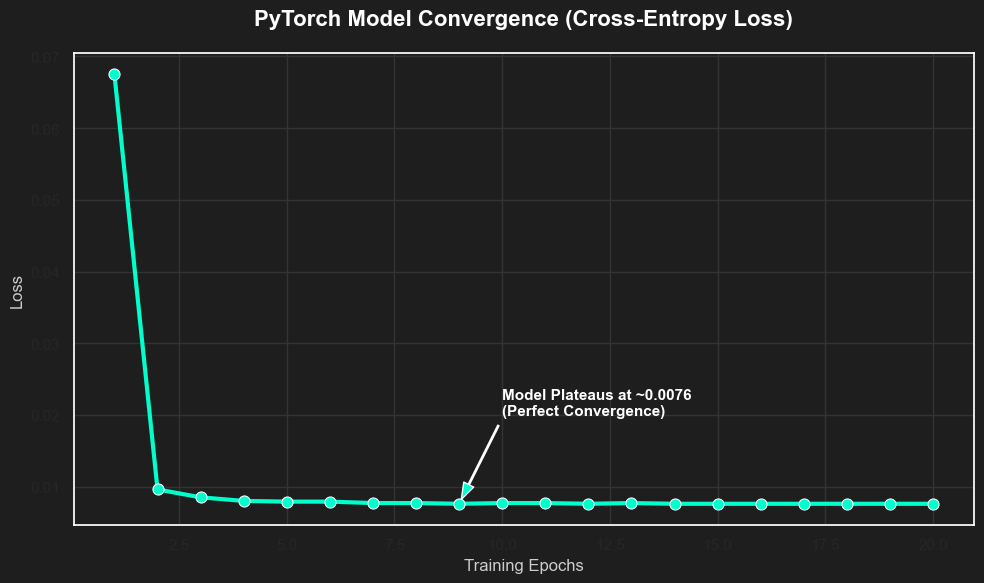

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Your exact loss data from earlier!
epochs = list(range(1, 21))
loss_values = [
    0.0675, 0.0096, 0.0085, 0.0080, 0.0079, 0.0079, 0.0077, 0.0077, 
    0.0076, 0.0077, 0.0077, 0.0076, 0.0077, 0.0076, 0.0076, 0.0076, 
    0.0076, 0.0076, 0.0076, 0.0076
]

# 2. Set up a beautiful dark-mode enterprise theme
plt.style.use('dark_background')
sns.set_theme(style="darkgrid", rc={"axes.facecolor": "#1e1e1e", "figure.facecolor": "#1e1e1e", "grid.color": "#333333"})

# 3. Create the figure
plt.figure(figsize=(10, 6))
sns.lineplot(x=epochs, y=loss_values, color="#00ffcc", linewidth=3, marker="o", markersize=8)

# 4. Add professional labels
plt.title("PyTorch Model Convergence (Cross-Entropy Loss)", fontsize=16, color="white", pad=20, fontweight="bold")
plt.xlabel("Training Epochs", fontsize=12, color="#cccccc")
plt.ylabel("Loss", fontsize=12, color="#cccccc")

# 5. Add an annotation for the plateau
plt.annotate(
    'Model Plateaus at ~0.0076\n(Perfect Convergence)', 
    xy=(9, 0.0076), xytext=(10, 0.02),
    arrowprops=dict(facecolor='#00ffcc', shrink=0.05, width=1, headwidth=8),
    color="white", fontsize=11, fontweight="bold"
)

# 6. Save the image to your folder
plt.tight_layout()
plt.savefig("loss_curve.png", dpi=300, bbox_inches='tight')
print("✅ Saved loss_curve.png!")

In [14]:
## Saving Model checkpoints after intense GPU training
torch.save(model.state_dict(), "ddxplus_model.pth")

import pickle

dataset_artifacts = {
    'disease_to_idx': dataset.disease_to_idx,
    'symptom_to_idx': dataset.symptom_to_idx,
    'all_symptoms': dataset.all_symptoms,
    'all_diseases': dataset.all_diseases
}

with open('ddxplus_mappings.pkl', 'wb') as file:
    pickle.dump(dataset_artifacts, file)

print(f'Model and Dataset artifacts saved successfully')

Model and Dataset artifacts saved successfully
